In [29]:
%cd /media/mohamed-gaber/01D96E17175F8760/Artifitial_intelligence/GraduationProject

/media/mohamed-gaber/01D96E17175F8760/Artifitial_intelligence/GraduationProject


# Libs and Packages

In [30]:
import logging , json

from typing import List, Optional, Dict , Any
from datetime import datetime
from enum import Enum
from pydantic import BaseModel, Field, ConfigDict
from datetime import datetime
from typing import Any, Dict, Literal

from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import END, START, StateGraph

from src.LLMs.Llama_Model   import get_llm_llama
from src.LLMs.Qwen_Model    import get_llm_qwn
from src.LLMs.GPT_OSS_Model import get_llm_oss

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

# Needed Classes

In [31]:
# =============================================================================
#  ENUMERATIONS
# =============================================================================

class Gender(str, Enum):
    MALE    = "ذكر"
    FEMALE  = "أنثى"
    UNKNOWN = "غير محدد"


class MentalState(str, Enum):
    SANE        = "سليم العقل"
    INSANE      = "مجنون"
    DIMINISHED  = "ناقص الأهلية"
    COERCED     = "مكره"
    DRUNK       = "سكران"
    UNKNOWN     = "غير محدد"


class LawCode(str, Enum):
    PENAL           = "قانون العقوبات"
    ANTI_DRUGS      = "قانون مكافحة المخدرات"
    ANTI_TERROR     = "قانون مكافحة الإرهاب"
    TRAFFIC         = "قانون المرور"
    FIREARMS        = "قانون الأسلحة والذخائر"
    CHILD           = "قانون الطفل"
    CYBER           = "قانون مكافحة جرائم المعلومات"
    ANTI_CORRUPTION = "قانون مكافحة الفساد"
    MONEY_LAUNDRY   = "قانون مكافحة غسيل الأموال"
    OTHER           = "قانون آخر"


class ComplicityRole(str, Enum):
    PRINCIPAL      = "فاعل أصلي"
    CO_PRINCIPAL   = "فاعل مشارك"
    ACCOMPLICE     = "شريك"
    INSTIGATOR     = "محرض"
    FACILITATOR    = "مساعد"
    UNKNOWN        = "غير محدد"


class EvidenceType(str, Enum):
    MATERIAL       = "دليل مادي"
    DOCUMENTARY    = "دليل مستندي"
    TESTIMONIAL    = "دليل شهادة"
    DIGITAL        = "دليل رقمي"
    FORENSIC       = "دليل جنائي"
    CONFESSION     = "اعتراف"
    CIRCUMSTANTIAL = "قرينة"
    OTHER          = "أخرى"


class ValidityStatus(str, Enum):
    VALID        = "سليم"
    QUESTIONABLE = "مشكوك فيه"
    INVALID      = "باطل"
    PENDING      = "قيد الفحص"


class WitnessType(str, Enum):
    PROSECUTION  = "شاهد إثبات"
    DEFENSE      = "شاهد نفي"
    VICTIM       = "مجني عليه"
    EXPERT       = "خبير"
    INFORMANT    = "مخبر"
    EYEWITNESS   = "شاهد عيان"
    CHARACTER    = "شاهد في شخصية المتهم"


class WitnessRelation(str, Enum):
    RELATIVE     = "قريب"
    FRIEND       = "صديق"
    ENEMY        = "عدو"
    COLLEAGUE    = "زميل"
    STRANGER     = "غريب"
    OFFICER      = "ضابط"
    UNKNOWN      = "غير محدد"


class ProcedureType(str, Enum):
    ARREST             = "قبض"
    SEARCH_PERSON      = "تفتيش شخص"
    SEARCH_PLACE       = "تفتيش مسكن"
    SEARCH_VEHICLE     = "تفتيش مركبة"
    INTERROGATION      = "استجواب"
    CONFRONTATION      = "مواجهة"
    LINEUP             = "عرض على المجني عليه"
    NOTIFICATION       = "إخطار نيابة"
    PRETRIAL_DETENTION = "حبس احتياطي"
    SEIZURE            = "ضبط"
    WIRETAP            = "تسجيل مكالمات"
    SURVEILLANCE       = "مراقبة"
    OTHER              = "إجراء آخر"


class NullityType(str, Enum):
    ABSOLUTE = "بطلان مطلق"
    RELATIVE = "بطلان نسبي"
    NONE     = "لا بطلان"


class CourtLevel(str, Enum):
    MISDEMEANOR  = "محكمة الجنح"
    CRIMINAL     = "محكمة الجنايات"
    APPEALS      = "محكمة الاستئناف"
    CASSATION    = "محكمة النقض"
    SUPREME      = "المحكمة العليا"
    ECONOMIC     = "المحكمة الاقتصادية"
    MILITARY     = "المحكمة العسكرية"
    JUVENILE     = "محكمة الأحداث"


class VerdictType(str, Enum):
    CONVICTION        = "إدانة"
    ACQUITTAL         = "براءة"
    DISMISSAL         = "قضية لا وجه لإقامة الدعوى"
    INSUFFICIENT_EVD  = "عدم كفاية الأدلة"
    NO_JURISDICTION   = "عدم الاختصاص"
    MISTRIAL          = "بطلان المحاكمة"


class IncidentType(str, Enum):
    HOMICIDE       = "قتل عمد"
    MANSLAUGHTER   = "قتل خطأ"
    ASSAULT        = "ضرب وجرح"
    ASSAULT_FATAL  = "ضرب أفضى إلى موت"
    ROBBERY        = "سطو مسلح"
    THEFT          = "سرقة"
    DRUG_POSSESS   = "حيازة مخدرات"
    DRUG_TRAFFIC   = "اتجار في مخدرات"
    RAPE           = "اغتصاب"
    SEXUAL_ASSAULT = "تحرش"
    FRAUD          = "نصب واحتيال"
    FORGERY        = "تزوير"
    TERROR         = "إرهاب"
    OTHER          = "أخرى"

# Entitie Classes

In [32]:
# =============================================================================
#  DEFENDANT
# =============================================================================

class Defendant(BaseModel):
    """
    بيانات المتهم المستخلصة من ملفات القضية.
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)

    # ── هوية ──────────────────────────────────────────────────────────────────
    name:               str
    alias:              Optional[str]       = None          # الاسم المستعار / اللقب
    national_id:        Optional[str]       = None
    passport_number:    Optional[str]       = None
    gender:             Optional[Gender]    = None
    age:                Optional[int]       = None          # ← بيأثر في التخفيف
    date_of_birth:      Optional[datetime]  = None
    nationality:        Optional[str]       = None
    occupation:         Optional[str]       = None          # ← بيأثر في ظروف التخفيف
    address:            Optional[str]       = None

    # ── حالة نفسية / قانونية ─────────────────────────────────────────────────
    mental_state:       Optional[MentalState] = None        # ← جنون / إكراه / سكر
    mental_report_id:   Optional[str]       = None          # مرجع تقرير الطب الشرعي النفسي

    # ── سوابق ──────────────────────────────────────────────────────────────────
    prior_record:       bool                = False
    prior_crimes:       List[str]           = Field(default_factory=list)  # ← نوع السوابق
    prior_sentences:    List[str]           = Field(default_factory=list)  # ← الأحكام السابقة

    # ── دور في الجريمة ────────────────────────────────────────────────────────
    complicity_role:    Optional[ComplicityRole] = None

    # ── وضع في القضية ────────────────────────────────────────────────────────
    in_custody:         Optional[bool]      = None
    arrest_date:        Optional[datetime]  = None
    detention_order_id: Optional[str]       = None          # رقم أمر الحبس الاحتياطي

    # ── مصدر البيانات ────────────────────────────────────────────────────────
    source_document_id: Optional[str]       = None
    notes:              Optional[str]       = None

In [33]:
# =============================================================================
#  CHARGE
# =============================================================================

class Charge(BaseModel):
    """
    التهم الموجهة — مستخلصة من أمر الإحالة أو قرار الاتهام.
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)

    # ── تعريف التهمة ──────────────────────────────────────────────────────────
    charge_id:              Optional[str]       = None      # معرف داخلي
    statute:                str                             # نص المادة
    law_code:               Optional[LawCode]   = None      # القانون المنطبق
    article_number:         Optional[str]       = None      # رقم المادة
    article_paragraph:      Optional[str]       = None      # فقرة المادة إن وجدت
    incident_type:          Optional[IncidentType] = None

    description:            Optional[str]       = None      # وصف التهمة
    charge_date:            Optional[datetime]  = None      # تاريخ ارتكاب الجريمة
    charge_location:        Optional[str]       = None      # مكان الجريمة

    # ── عناصر الجريمة ────────────────────────────────────────────────────────
    elements_required:      List[str]           = Field(default_factory=list)  # أركان الجريمة
    elements_proven:        Dict[str, bool]     = Field(default_factory=dict)  # ← ثبت / لم يثبت

    # ── درجة الجريمة ─────────────────────────────────────────────────────────
    attempt_flag:           bool                = False      # شروع أم جريمة تامة؟
    complicity_role:        Optional[ComplicityRole] = None  # فاعل / شريك / محرض

    # ── العقوبة ───────────────────────────────────────────────────────────────
    penalty_range:          Optional[str]       = None      # الحد الأدنى والأقصى
    penalty_min:            Optional[str]       = None      # الحد الأدنى
    penalty_max:            Optional[str]       = None      # الحد الأقصى

    # ── ظروف ──────────────────────────────────────────────────────────────────
    aggravating_factors:    List[str]           = Field(default_factory=list)  # ظروف مشددة
    mitigating_factors:     List[str]           = Field(default_factory=list)  # ظروف مخففة

    # ── ربط بمتهمين ───────────────────────────────────────────────────────────
    linked_defendant_names: List[str]           = Field(default_factory=list)

    # ── مصدر ──────────────────────────────────────────────────────────────────
    source_document_id:     Optional[str]       = None
    notes:                  Optional[str]       = None

In [34]:
# =============================================================================
#  EVIDENCE
# =============================================================================

class Evidence(BaseModel):
    """
    الأدلة المادية والمستندية المضبوطة.
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)

    # ── هوية الدليل ───────────────────────────────────────────────────────────
    evidence_id:                Optional[str]           = None
    evidence_type:              Optional[EvidenceType]  = None
    description:                Optional[str]           = None

    # ── الضبط ─────────────────────────────────────────────────────────────────
    seizure_date:               Optional[datetime]      = None   # تاريخ الضبط
    seizure_location:           Optional[str]           = None   # مكان الضبط ← مهم للتفتيش
    seized_by:                  Optional[str]           = None   # ضابط/مخبر ضبطه
    seizure_warrant_present:    Optional[bool]          = None   # هل في إذن تفتيش؟

    # ── سلسلة الحيازة ────────────────────────────────────────────────────────
    chain_of_custody_ok:        Optional[bool]          = None   # سلامة سلسلة الحيازة
    chain_of_custody_notes:     Optional[str]           = None   # ملاحظات سلسلة الحيازة
    storage_conditions_ok:      Optional[bool]          = None   # ظروف التخزين سليمة؟

    # ── الصلاحية ──────────────────────────────────────────────────────────────
    validity_status:            Optional[ValidityStatus] = None
    invalidity_reason:          Optional[str]           = None   # سبب البطلان إن وُجد

    # ── الربط ─────────────────────────────────────────────────────────────────
    linked_charge_ids:          List[str]               = Field(default_factory=list)
    linked_charge_elements:     List[str]               = Field(default_factory=list)
    linked_defendant_name:      Optional[str]           = None   # بيخص متهم معين

    # ── مصدر ──────────────────────────────────────────────────────────────────
    source_document_id:         Optional[str]           = None
    page_reference:             Optional[str]           = None   # رقم الصفحة في الملف
    notes:                      Optional[str]           = None

In [35]:
# =============================================================================
#  LAB REPORT
# =============================================================================

class LabReport(BaseModel):
    """
    تقارير الطب الشرعي والمعامل الجنائية.
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)

    # ── هوية التقرير ──────────────────────────────────────────────────────────
    report_id:                  Optional[str]       = None
    report_type:                Optional[str]       = None   # كيمياء / دم / بصمات / DNA / سموم
    lab_name:                   Optional[str]       = None   # اسم المعمل / الجهة
    examiner_name:              Optional[str]       = None   # اسم الخبير
    examination_date:           Optional[datetime]  = None

    # ── العينة ────────────────────────────────────────────────────────────────
    sample_id:                  Optional[str]       = None
    sample_type:                Optional[str]       = None   # دم / مسحة / بصمة / سلاح
    sample_source:              Optional[str]       = None   # من أين أُخذت العينة
    sample_chain_intact:        Optional[bool]      = None   # سلسلة حيازة العينة سليمة؟

    # ── النتيجة ───────────────────────────────────────────────────────────────
    result:                     Optional[str]       = None
    result_is_positive:         Optional[bool]      = None   # إيجابي / سلبي
    confirms_charge_element:    Optional[bool]      = None   # يثبت ركن من أركان التهمة؟
    linked_charge_element:      Optional[str]       = None   # أي ركن؟

    # ── الربط ─────────────────────────────────────────────────────────────────
    linked_evidence_id:         Optional[str]       = None
    linked_defendant_name:      Optional[str]       = None

    # ── مصدر ──────────────────────────────────────────────────────────────────
    source_document_id:         Optional[str]       = None
    notes:                      Optional[str]       = None

In [36]:
# =============================================================================
#  WITNESS STATEMENT
# =============================================================================

class WitnessStatement(BaseModel):
    """
    أقوال الشهود المستخلصة من محاضر التحقيق والمحاكمة.
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)

    # ── هوية الشاهد ───────────────────────────────────────────────────────────
    witness_name:               str
    witness_national_id:        Optional[str]           = None
    witness_type:               Optional[WitnessType]   = None
    witness_occupation:         Optional[str]           = None
    relation_to_defendant:      Optional[WitnessRelation] = None  # قريب / عدو / محايد / ضابط

    # ── الإجراءات ─────────────────────────────────────────────────────────────
    statement_date:             Optional[datetime]      = None
    statement_stage:            Optional[str]           = None   # تحقيق / محاكمة / نيابة
    was_sworn_in:               Optional[bool]          = None   # أدى اليمين؟ ← إجرائي مهم
    presence_at_scene:          Optional[bool]          = None   # كان موجود في مكان الجريمة؟

    # ── المضمون ───────────────────────────────────────────────────────────────
    statement_summary:          Optional[str]           = None
    key_facts_mentioned:        List[str]               = Field(default_factory=list)  # وقائع ذكرها

    # ── الاتساق ───────────────────────────────────────────────────────────────
    consistency_flag:           Optional[bool]          = None   # متسق مع باقي الأدلة؟
    contradicts_other_evidence: Optional[bool]          = None
    contradiction_details:      Optional[str]           = None   # تفاصيل التناقض
    prior_statement_exists:     Optional[bool]          = None   # أدلى بأقوال سابقة؟
    retracted_statement:        Optional[bool]          = None   # عدل عن أقواله؟

    # ── الموثوقية ─────────────────────────────────────────────────────────────
    credibility_flags:          List[str]               = Field(default_factory=list)  # عوامل تأثر الموثوقية

    # ── مصدر ──────────────────────────────────────────────────────────────────
    source_document_id:         Optional[str]           = None
    page_reference:             Optional[str]           = None
    notes:                      Optional[str]           = None

In [37]:
# =============================================================================
#  CONFESSION
# =============================================================================

class Confession(BaseModel):
    """
    اعترافات المتهمين — بيانات الاستخلاص الإجرائي والموضوعي.
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)

    # ── هوية ──────────────────────────────────────────────────────────────────
    confession_id:              Optional[str]       = None
    defendant_name:             str

    # ── الظروف الإجرائية ─────────────────────────────────────────────────────
    confession_date:            Optional[datetime]  = None
    confession_stage:           Optional[str]       = None   # شرطة / نيابة / محكمة
    obtained_before_arrest:     Optional[bool]      = None   # قبل القبض الرسمي؟
    obtained_after_arrest:      Optional[bool]      = None   # ← بعد القبض؟ — إجرائي حاسم
    legal_counsel_present:      Optional[bool]      = None   # ← حضر محامي؟ — حق دستوري
    informed_of_rights:         Optional[bool]      = None   # أُخبر بحقوقه؟
    coercion_claimed:           Optional[bool]      = None   # ادعى الإكراه؟
    coercion_evidence:          Optional[str]       = None   # دليل على الإكراه المزعوم

    # ── المضمون ───────────────────────────────────────────────────────────────
    text:                       Optional[str]       = None   # نص الاعتراف
    key_admissions:             List[str]           = Field(default_factory=list)  # الاعترافات الجوهرية

    # ── الموثوقية ─────────────────────────────────────────────────────────────
    voluntary:                  Optional[bool]      = None   # طوعي؟
    consistent_with_facts:      Optional[bool]      = None   # يتسق مع وقائع القضية؟
    consistent_with_evidence:   Optional[bool]      = None   # يتسق مع الأدلة المادية؟
    retracted:                  Optional[bool]      = None   # ← عدل عنه؟ — مهم جدًا
    retraction_date:            Optional[datetime]  = None
    retraction_reason:          Optional[str]       = None   # سبب العدول

    # ── مصدر ──────────────────────────────────────────────────────────────────
    source_document_id:         Optional[str]       = None
    page_reference:             Optional[str]       = None
    notes:                      Optional[str]       = None

In [38]:
# =============================================================================
#  PROCEDURAL ISSUE
# =============================================================================

class ProceduralIssue(BaseModel):
    """
    المسائل الإجرائية المستخلصة من ملفات القضية —
    تُمرَّر لـ Procedural Auditor Agent للتقييم القانوني.
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)

    # ── تعريف الإجراء ─────────────────────────────────────────────────────────
    issue_id:                   Optional[str]           = None
    procedure_type:             Optional[ProcedureType] = None
    procedure_date:             Optional[datetime]      = None
    conducting_officer:         Optional[str]           = None   # من أجرى الإجراء
    conducting_authority:       Optional[str]           = None   # الجهة (شرطة / نيابة / قاضي)

    # ── السلامة الإجرائية ─────────────────────────────────────────────────────
    warrant_present:            Optional[bool]          = None   # وجود إذن / أمر قضائي
    warrant_id:                 Optional[str]           = None   # رقم الإذن
    notification_to_da:         Optional[bool]          = None   # تم إخطار النيابة؟
    notification_time:          Optional[str]           = None   # وقت الإخطار
    legal_timeframes_respected: Optional[bool]          = None   # المواعيد القانونية ملتزم بها؟

    # ── المشكلة المستخلصة ─────────────────────────────────────────────────────
    issue_description:          Optional[str]           = None   # وصف الإشكالية الإجرائية
    nullity_type:               Optional[NullityType]   = None   # بطلان مطلق / نسبي / لا بطلان
    article_basis:              Optional[str]           = None   # المادة القانونية للبطلان المزعوم

    # ── الأثر ─────────────────────────────────────────────────────────────────
    affects_evidence_ids:       List[str]               = Field(default_factory=list)
    may_invalidate_case:        Optional[bool]          = None
    tainted_fruit_risk:         Optional[bool]          = None   # خطر ثمرة الشجرة المسمومة

    # ── مصدر ──────────────────────────────────────────────────────────────────
    source_document_id:         Optional[str]           = None
    page_reference:             Optional[str]           = None
    notes:                      Optional[str]           = None

In [39]:
# =============================================================================
#  PRIOR JUDGMENT  (مستخلص من أحكام سابقة — للمقارنة والاستدلال)
# =============================================================================

class PriorJudgment(BaseModel):
    """
    بيانات الأحكام السابقة المستخلصة — للاستدلال القانوني والمقارنة.
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)

    # ── تعريف الحكم ───────────────────────────────────────────────────────────
    judgment_id:                Optional[str]           = None
    case_reference:             Optional[str]           = None   # رقم القضية
    court_name:                 Optional[str]           = None
    court_level:                Optional[CourtLevel]    = None
    verdict_date:               Optional[datetime]      = None
    verdict_type:               Optional[VerdictType]   = None

    # ── موضوع الحكم ───────────────────────────────────────────────────────────
    charge_statutes:            List[str]               = Field(default_factory=list)
    key_legal_principles:       List[str]               = Field(default_factory=list)  # مبادئ قانونية مقررة
    penalty_imposed:            Optional[str]           = None

    # ── الاستخدام ─────────────────────────────────────────────────────────────
    relevance_to_current_case:  Optional[str]           = None   # أوجه الصلة بالقضية الحالية

    # ── مصدر ──────────────────────────────────────────────────────────────────
    source_document_id:         Optional[str]           = None
    notes:                      Optional[str]           = None

In [40]:
# =============================================================================
#  DEFENSE DOCUMENT  (مستندات الدفاع)
# =============================================================================

class DefenseDocument(BaseModel):
    """
    مستندات ومذكرات الدفاع المستخلصة.
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)

    # ── تعريف ─────────────────────────────────────────────────────────────────
    doc_id:                     Optional[str]           = None
    doc_type:                   Optional[str]           = None   # مذكرة / تقرير طبي / حجج دفاع
    submission_date:            Optional[datetime]      = None
    submitted_by:               Optional[str]           = None   # المحامي / المتهم

    # ── الدفوع المستخلصة ──────────────────────────────────────────────────────
    formal_defenses:            List[str]               = Field(default_factory=list)   # دفوع شكلية
    substantive_defenses:       List[str]               = Field(default_factory=list)   # دفوع موضوعية
    alibi_claimed:              Optional[bool]          = None   # ادعاء حضوري في مكان آخر؟
    alibi_details:              Optional[str]           = None

    # ── الأدلة الدفاعية ───────────────────────────────────────────────────────
    defense_evidence_ids:       List[str]               = Field(default_factory=list)
    supporting_principles:      List[str]               = Field(default_factory=list)   # مبادئ نقض مستشهد بها

    # ── مصدر ──────────────────────────────────────────────────────────────────
    source_document_id:         Optional[str]           = None
    notes:                      Optional[str]           = None

In [41]:
# =============================================================================
#  CASE INCIDENT  (وقائع القضية الأساسية)
# =============================================================================

class CaseIncident(BaseModel):
    """
    الوقائع الجوهرية للقضية المستخلصة من محاضر الضبط والتحقيق.
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)

    incident_id:                Optional[str]           = None
    incident_type:              Optional[IncidentType]  = None
    incident_date:              Optional[datetime]      = None
    incident_location:          Optional[str]           = None
    incident_description:       Optional[str]           = None

    # ── الأطراف ───────────────────────────────────────────────────────────────
    perpetrator_names:          List[str]               = Field(default_factory=list)
    victim_names:               List[str]               = Field(default_factory=list)
    witness_names:              List[str]               = Field(default_factory=list)

    # ── النتيجة ───────────────────────────────────────────────────────────────
    outcome:                    Optional[str]           = None   # نتيجة الواقعة (وفاة / إصابة / خسارة مالية)
    outcome_severity:           Optional[str]           = None   # درجة الخطورة

    # ── الربط ─────────────────────────────────────────────────────────────────
    linked_evidence_ids:        List[str]               = Field(default_factory=list)
    linked_charge_ids:          List[str]               = Field(default_factory=list)

    source_document_id:         Optional[str]           = None
    notes:                      Optional[str]           = None

In [42]:
# =============================================================================
#  AGENT STATE  (الحالة الكاملة للقضية)
# =============================================================================

class AgentState(BaseModel):
    """
    الحالة الكاملة للقضية — تجمع كل المعطيات المستخلصة من الوثائق.
    تُمرَّر بين الـ Agents عبر LangGraph.
    """
    model_config = ConfigDict(
        arbitrary_types_allowed=True,
        extra="ignore"
    )

    # ── معرّفات القضية ────────────────────────────────────────────────────────
    case_id:                str
    case_number:            Optional[str]       = None   # رقم القضية الرسمي
    court:                  Optional[str]       = None
    court_level:            Optional[CourtLevel] = None
    jurisdiction:           Optional[str]       = None   # الدائرة / المحكمة
    filing_date:            Optional[datetime]  = None
    referral_date:          Optional[datetime]  = None   # تاريخ إحالة للمحاكمة
    prosecutor_name:        Optional[str]       = None

    # ── الكيانات المستخلصة ───────────────────────────────────────────────────
    defendants:             List[Defendant]          = Field(default_factory=list)
    charges:                List[Charge]             = Field(default_factory=list)
    incidents:              List[CaseIncident]        = Field(default_factory=list)
    evidences:              List[Evidence]            = Field(default_factory=list)
    lab_reports:            List[LabReport]           = Field(default_factory=list)
    witness_statements:     List[WitnessStatement]    = Field(default_factory=list)
    confessions:            List[Confession]          = Field(default_factory=list)
    procedural_issues:      List[ProceduralIssue]     = Field(default_factory=list)
    prior_judgments:        List[PriorJudgment]       = Field(default_factory=list)
    defense_documents:      List[DefenseDocument]     = Field(default_factory=list)

    # ── مخرجات الـ Agents (تُملأ تدريجيًا) ──────────────────────────────────
    agent_outputs:          Dict[str, Any]       = Field(default_factory=dict)

    # ── تتبع الحالة ───────────────────────────────────────────────────────────
    completed_agents:       List[str]            = Field(default_factory=list)
    current_agent:          Optional[str]        = None
    errors:                 List[str]            = Field(default_factory=list)

    # ── الحكم النهائي (يُملأ فقط بواسطة Judge Agent) ─────────────────────────
    suggested_verdict:      Optional[VerdictType]  = None
    confidence_score:       Optional[float]        = None   # 0.0 → 1.0
    reasoning_trace:        Optional[List[Dict[str, str]]] = None

    # ── ميتاداتا ──────────────────────────────────────────────────────────────
    source_documents:       List[str]            = Field(default_factory=list)  # قائمة الملفات المدخلة
    last_updated:           Optional[datetime]   = None
    extraction_notes:       Optional[str]        = None

# Helpers

In [43]:
# =============================================================================
#  HELPERS
# =============================================================================


def _build_charge_query(charge: "Charge") -> str:
    """
    يبني query نصي من حقول التهمة لتحقيق أفضل recall في البحث.
    يرتب الحقول من الأكثر تخصصًا للأقل.
    """
    parts = []

    # الأكثر تخصصًا أولًا
    if charge.article_number:
        parts.append(f"المادة {charge.article_number}")
    if charge.statute:
        parts.append(charge.statute)
    if charge.law_code:
        parts.append(str(charge.law_code))
    if charge.description:
        parts.append(charge.description)
    # أركان الجريمة تثري البحث في مبادئ النقض
    if charge.elements_required:
        parts.append(" ".join(charge.elements_required[:4]))
    if charge.aggravating_factors:
        parts.append(" ".join(charge.aggravating_factors[:2]))

    return " | ".join(parts)


def _docs_to_text_list(docs: list, max_chars: int = 500) -> list[dict]:
    result = []
    for doc in docs:
        meta = doc.metadata or {}
        result.append({
            "content":        doc.page_content[:max_chars],  # ← trim here
            "law_id":         meta.get("law_id"),
            "article_number": meta.get("article_number"),
            "chunk_type":     meta.get("chunk_type"),
            "law_title":      meta.get("law_title"),
            "crime_category": meta.get("crime_category"),
            "chunk_id":       meta.get("chunk_id"),
        })
    return result

def _lawcode_to_law_id(charge: "Charge") -> str | None:
    if not charge.law_code:
        return None
    mapping = {
        "قانون العقوبات":               "penal_code",
        "قانون مكافحة المخدرات":         "anti_drugs",
        "قانون مكافحة الإرهاب":          "anti_terror",
        "قانون الأسلحة والذخائر":        "weapons_ammunition",
        "قانون مكافحة جرائم المعلومات":  "cybercrime",
        "قانون مكافحة غسيل الأموال":     "money_laundering",
    }
    return mapping.get(str(charge.law_code))  # None = no filter

def _retrieve_for_charge(
    charge:     "Charge",
    lv:         "LegalVectorStore",
    kg:         "LegalKnowledgeGraph",
    k_statutes: int = 6,
    k_cassation: int = 6,
) -> dict:
    """
    Hybrid retrieval:
      1. FAISS vector search  → top-k semantically similar articles
      2. KG Cypher expansion  → penalties, definitions, amendments,
                                cross-references for those articles
      3. Na2d FAISS search    → cassation rulings + principles
    """
    query = _build_charge_query(charge)

    # ── 1. FAISS: semantic search for relevant articles ───────────────────────
    statute_docs = []
    try:
        statute_docs = lv.search_laws(
            query      = query,
            k          = k_statutes,
            law_id     = _lawcode_to_law_id(charge),
        )
        logger.info("    📖 FAISS statutes: %d", len(statute_docs))
    except Exception as e:
        logger.warning("    ⚠️  FAISS statutes failed: %s", e)

    # ── 2. KG expansion: for each retrieved article, pull its full subgraph ───
    kg_context = {}
    article_numbers = [
        d.metadata.get("article_number")
        for d in statute_docs
        if d.metadata.get("article_number")
    ]
    law_id = _lawcode_to_law_id(charge)

    if article_numbers and law_id:
        try:
            with kg.driver.session() as session:

                # ── Penalties for these articles ──────────────────────────────
                penalties = session.run("""
                    MATCH (a:Article {law_id: $law_id})-[:HAS_PENALTY]->(p:Penalty)
                    WHERE a.article_number IN $article_numbers
                    RETURN a.article_number AS article, 
                           p.penalty_type  AS type,
                           p.min_value     AS min,
                           p.max_value     AS max,
                           p.unit          AS unit
                """, law_id=law_id, article_numbers=article_numbers).data()

                # ── Definitions inside these articles ─────────────────────────
                definitions = session.run("""
                    MATCH (a:Article {law_id: $law_id})-[:DEFINES]->(d:Definition)
                    WHERE a.article_number IN $article_numbers
                    RETURN a.article_number AS article,
                           d.term           AS term,
                           d.definition_text AS text
                """, law_id=law_id, article_numbers=article_numbers).data()

                # ── Articles referenced BY these articles ─────────────────────
                references = session.run("""
                    MATCH (a:Article {law_id: $law_id})-[:REFERENCES]->(ref:Article)
                    WHERE a.article_number IN $article_numbers
                    RETURN a.article_number   AS from_article,
                           ref.article_number AS to_article,
                           ref.text           AS ref_text
                    LIMIT 10
                """, law_id=law_id, article_numbers=article_numbers).data()

                # ── Amendments that touched these articles ────────────────────
                amendments = session.run("""
                    MATCH (a:Article {law_id: $law_id})-[:AMENDED_BY]->(am:Amendment)
                    WHERE a.article_number IN $article_numbers
                    RETURN a.article_number      AS article,
                           am.amendment_date     AS date,
                           am.amendment_type     AS type,
                           am.description        AS description
                    ORDER BY am.amendment_date DESC
                    LIMIT 5
                """, law_id=law_id, article_numbers=article_numbers).data()

                # ── Latest (superseding) version of these articles ────────────
                latest_versions = session.run("""
                    MATCH (new:Article)-[:SUPERSEDES]->(old:Article {law_id: $law_id})
                    WHERE old.article_number IN $article_numbers
                    RETURN old.article_number AS article,
                           new.text           AS latest_text,
                           new.version        AS version
                    ORDER BY new.version DESC
                """, law_id=law_id, article_numbers=article_numbers).data()

                # ── Aggravating/mitigating topics linked to these articles ─────
                topics = session.run("""
                    MATCH (a:Article {law_id: $law_id})-[:TAGGED_WITH]->(t:Topic)
                    WHERE a.article_number IN $article_numbers
                    RETURN a.article_number AS article,
                           t.name           AS topic
                """, law_id=law_id, article_numbers=article_numbers).data()

            kg_context = {
                "penalties":       penalties,
                "definitions":     definitions,
                "references":      references,
                "amendments":      amendments,
                "latest_versions": latest_versions,
                "topics":          topics,
            }
            logger.info(
                "    🕸️  KG expanded: %d penalties | %d defs | %d refs | %d amendments",
                len(penalties), len(definitions), len(references), len(amendments)
            )
        except Exception as e:
            logger.warning("    ⚠️  KG expansion failed: %s", e)

    # ── 3. FAISS: cassation rulings + principles ──────────────────────────────
    cassation_docs = []
    try:
        cassation_docs = lv.search_na2d(
            query          = query,
            k              = k_cassation,
            source         = "both",
            crime_category = _map_incident_to_crime_category(charge),
        )
        logger.info("    ⚖️  Cassation: %d docs", len(cassation_docs))
    except Exception as e:
        logger.warning("    ⚠️  Cassation retrieval failed: %s", e)

    return {
        "charge_statute":   charge.statute,
        "article_number":   charge.article_number,
        "law_code":         str(charge.law_code) if charge.law_code else None,
        "incident_type":    str(charge.incident_type) if charge.incident_type else None,
        "query_used":       query,
        # FAISS results
        "statute_docs":     _docs_to_text_list(statute_docs),
        "cassation_docs":   _docs_to_text_list(cassation_docs),
        # KG structured expansion ← هذا هو الفرق الحقيقي
        "kg_context":       kg_context,
    }

def _map_incident_to_crime_category(charge: "Charge") -> str | None:
    """
    يحاول تحويل IncidentType إلى crime_category يفهمه Na2dRetriever.
    يعيد None إذا لم يكن هناك تطابق — فيبحث بدون تصفية.
    """
    if not charge.incident_type:
        return None

    # هذا الـ mapping مبني على القيم الموجودة في metadata.crime_category
    # في قاعدة بياناتك — عدّله حسب قيمك الفعلية
    mapping = {
        "قتل عمد":             "قتل",
        "قتل خطأ":             "قتل",
        "ضرب وجرح":            "جرائم الإيذاء",
        "ضرب أفضى إلى موت":    "جرائم الإيذاء",
        "سطو مسلح":            "سرقة",
        "سرقة":                "سرقة",
        "حيازة مخدرات":        "مخدرات",
        "اتجار في مخدرات":     "مخدرات",
        "اغتصاب":              "جرائم الشرف",
        "تحرش":                "جرائم الشرف",
        "نصب واحتيال":         "غش وتدليس",
        "تزوير":               "تزوير",
        "إرهاب":               "إرهاب",
    }
    return mapping.get(str(charge.incident_type))


def _build_fallback_package(contexts: list[dict]) -> dict:
    """
    يبني حزمة بحث مبسطة من النصوص المسترجعة مباشرة
    في حالة فشل الـ LLM أو خطأ JSON parsing.
    الـ _fallback flag يُخبر Judge Agent إن البحث ناقص.
    """
    return {
        "research_packages": [
            {
                "charge_statute":       ctx["charge_statute"],
                "law_code":             ctx.get("law_code"),
                "article_number":       ctx.get("article_number"),
                "elements_of_crime":    [],
                "statutes": [
                    d["content"]
                    for d in ctx.get("statute_docs", [])[:3]
                ],
                "aggravating_articles": [],
                "mitigating_articles":  [],
                "principles": [
                    d["content"]
                    for d in ctx.get("cassation_docs", [])[:3]
                ],
                "precedents":           [],
                "penalty_range":        "يحدده القاضي — فشل استخلاص العقوبة",
            }
            for ctx in contexts
        ],
        "procedural_principles":      [],
        "relevant_cassation_rulings": [],
        "_fallback": True,
    }





def _read_file(file_path: str) -> tuple[str, str]:
    """
    يقرأ ملف .txt أو .pdf ويُعيد (النص الخام، نوع الملف).
    لا OCR — فقط نصوص مباشرة.

    Returns:
        (raw_text, file_extension)

    Raises:
        ValueError: إذا كان الملف غير مدعوم أو غير موجود.
    """
    import os
    from pathlib import Path

    path = Path(file_path)

    if not path.exists():
        raise ValueError(f"الملف غير موجود: {file_path}")

    ext = path.suffix.lower()

    if ext == ".txt":
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            return f.read(), "txt"

    elif ext == ".pdf":
        try:
            import pdfplumber
            text_parts = []
            with pdfplumber.open(path) as pdf:
                for page_num, page in enumerate(pdf.pages, start=1):
                    page_text = page.extract_text()
                    if page_text and page_text.strip():
                        text_parts.append(f"[صفحة {page_num}]\n{page_text}")
            if not text_parts:
                raise ValueError(f"الملف {file_path} لا يحتوي على نص قابل للاستخراج (مسح ضوئي غير مدعوم)")
            return "\n\n".join(text_parts), "pdf"

        except ImportError:
            raise ImportError(
                "مكتبة pdfplumber غير مثبتة. "
                "ثبّتها بـ: pip install pdfplumber"
            )

    else:
        raise ValueError(
            f"نوع الملف غير مدعوم: {ext} — المدعوم فقط: .txt و .pdf"
        )


def _chunk_text(text: str, chunk_size: int = 3000, overlap: int = 200) -> list[str]:
    """
    يقسم النص إلى chunks مع تداخل للحفاظ على السياق عند الحدود.
    chunk_size بالأحرف لا بالكلمات — مناسب للعربية.
    """
    if len(text) <= chunk_size:
        return [text]

    chunks   = []
    start    = 0
    text_len = len(text)

    while start < text_len:
        end = min(start + chunk_size, text_len)

        # محاولة القطع عند فاصل طبيعي (سطر جديد أو نقطة)
        if end < text_len:
            for sep in ("\n\n", "\n", ".", "،"):
                last_sep = text.rfind(sep, start + chunk_size // 2, end)
                if last_sep != -1:
                    end = last_sep + len(sep)
                    break

        chunks.append(text[start:end].strip())
        start = max(start + 1, end - overlap)   # overlap للسياق

    return [c for c in chunks if c]


def _merge_extracted(base: dict, new: dict) -> dict:
    """
    يدمج نتائج استخلاص chunk جديد مع ما تم استخلاصه مسبقًا.
    القوائم تُضاف، القاموس المفرد (case_meta) يُحدَّث بالقيم غير الـ null فقط.
    """
    merged = {k: v for k, v in base.items()}

    # case_meta: خذ القيمة الأولى غير null لكل حقل
    if "case_meta" in new and "case_meta" in merged:
        for k, v in new["case_meta"].items():
            if v is not None and merged["case_meta"].get(k) is None:
                merged["case_meta"][k] = v
    elif "case_meta" in new:
        merged["case_meta"] = new["case_meta"]

    # القوائم: أضف عناصر جديدة فقط (تجنب التكرار بناءً على الاسم/الـ ID)
    list_fields = [
        "defendants", "charges", "incidents", "evidences",
        "lab_reports", "witness_statements", "confessions",
        "procedural_issues", "prior_judgments", "defense_documents",
    ]

    id_keys = {
        "defendants":         "name",
        "charges":            "charge_id",
        "incidents":          "incident_id",
        "evidences":          "evidence_id",
        "lab_reports":        "report_id",
        "witness_statements": "witness_name",
        "confessions":        "confession_id",
        "procedural_issues":  "issue_id",
        "prior_judgments":    "judgment_id",
        "defense_documents":  "doc_id",
    }

    for field in list_fields:
        if field not in new:
            continue

        existing  = merged.get(field, [])
        id_key    = id_keys[field]
        seen_ids  = {item.get(id_key) for item in existing if item.get(id_key)}

        for item in new.get(field, []):
            item_id = item.get(id_key)
            if item_id and item_id in seen_ids:
                continue    # مكرر — تجاهل
            existing.append(item)
            if item_id:
                seen_ids.add(item_id)

        merged[field] = existing

    return merged


def _parse_llm_json(raw: str) -> dict:
    """
    يستخرج JSON من استجابة الـ LLM بشكل آمن،
    يتعامل مع markdown code blocks والمسافات الزائدة.
    """
    import re
    text = raw.strip()

    # إزالة ```json ... ``` إن وُجد
    match = re.search(r"```(?:json)?\s*([\s\S]+?)\s*```", text)
    if match:
        text = match.group(1).strip()

    # إزالة أي نص قبل أول `{`
    brace_start = text.find("{")
    if brace_start > 0:
        text = text[brace_start:]

    return json.loads(text)


def _apply_extracted_to_state(state: AgentState, extracted: dict, doc_id: str) -> dict:
    """
    يحوّل الـ dict المستخلص من الـ LLM إلى Pydantic objects ويدمجها في الـ state.
    يُعيد dict يُمرَّر لـ model_copy.
    """
    def _safe_parse(model_cls, data: dict):
        """يُنشئ Pydantic object بشكل آمن — يتجاهل الحقول غير المعروفة."""
        try:
            return model_cls.model_validate(data)
        except Exception as e:
            logger.warning("⚠️  Failed to parse %s from %s: %s", model_cls.__name__, doc_id, e)
            return None

    updates: dict = {}

    # ── case_meta ─────────────────────────────────────────────────────────────
    meta = extracted.get("case_meta", {})
    if meta:
        if state.case_number is None and meta.get("case_number"):
            updates["case_number"] = meta["case_number"]
        if state.court is None and meta.get("court"):
            updates["court"] = meta["court"]
        if state.jurisdiction is None and meta.get("jurisdiction"):
            updates["jurisdiction"] = meta["jurisdiction"]
        if state.prosecutor_name is None and meta.get("prosecutor_name"):
            updates["prosecutor_name"] = meta["prosecutor_name"]
        # court_level و dates: تحتاج تحويل enum/datetime — يعالجهم Pydantic في AgentState

    # ── lists ─────────────────────────────────────────────────────────────────
    field_map = {
        "defendants":         (Defendant,        "defendants"),
        "charges":            (Charge,           "charges"),
        "incidents":          (CaseIncident,     "incidents"),
        "evidences":          (Evidence,         "evidences"),
        "lab_reports":        (LabReport,        "lab_reports"),
        "witness_statements": (WitnessStatement, "witness_statements"),
        "confessions":        (Confession,       "confessions"),
        "procedural_issues":  (ProceduralIssue,  "procedural_issues"),
        "prior_judgments":    (PriorJudgment,    "prior_judgments"),
        "defense_documents":  (DefenseDocument,  "defense_documents"),
    }

    for json_key, (model_cls, state_field) in field_map.items():
        raw_list = extracted.get(json_key, [])
        if not raw_list:
            continue

        existing   = list(getattr(state, state_field))
        new_parsed = []

        for raw_item in raw_list:
            # تأكد من وجود source_document_id
            if "source_document_id" not in raw_item or not raw_item["source_document_id"]:
                raw_item["source_document_id"] = doc_id

            obj = _safe_parse(model_cls, raw_item)
            if obj is not None:
                new_parsed.append(obj)

        if new_parsed:
            updates[state_field] = existing + new_parsed

    return updates


def _now() -> datetime:
    from datetime import timezone
    return datetime.now(timezone.utc)


def _json_safe(obj) -> Any:
    """
    Recursively converts non-JSON-serializable types (datetime, Enum)
    to their string representations so json.dumps never raises TypeError.
    """
    from enum import Enum as _Enum
    if isinstance(obj, datetime):
        return obj.isoformat()
    if isinstance(obj, _Enum):
        return obj.value
    if isinstance(obj, dict):
        return {k: _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_safe(i) for i in obj]
    return obj


def _safe_dump(pydantic_obj) -> dict:
    """model_dump() + _json_safe — always returns a JSON-serialisable dict."""
    return _json_safe(pydantic_obj.model_dump())


def _state_summary(state: AgentState) -> str:
    """Compact JSON snapshot fed into every Agent's system prompt."""
    return json.dumps(
        {
            "case_id":           state.case_id,
            "case_number":       state.case_number,
            "court":             state.court,
            "defendants":        [d.name for d in state.defendants],
            "charges":           [c.statute for c in state.charges],
            "incident_types":    [i.incident_type for i in state.incidents if i.incident_type],
            "evidence_count":    len(state.evidences),
            "witness_count":     len(state.witness_statements),
            "confession_count":  len(state.confessions),
            "procedural_issues": len(state.procedural_issues),
            "completed_agents":  state.completed_agents,
        },
        ensure_ascii=False,
        indent=2,
    )


def _agent_context(state: AgentState, agent_name: str) -> str:
    """Build the approved context window for a specific agent."""
    base = _state_summary(state)

    extra: Dict[str, Any] = {}

    if agent_name == "procedural_auditor":
        extra = {
            "procedural_issues": [_safe_dump(p) for p in state.procedural_issues],
            "confessions":       [_safe_dump(c) for c in state.confessions],
            "evidences":         [_safe_dump(e) for e in state.evidences],
        }
    elif agent_name == "legal_researcher":
        extra = {
            "charges":           [_safe_dump(c) for c in state.charges],
            "incidents":         [_safe_dump(i) for i in state.incidents],
            "prior_judgments":   [_safe_dump(j) for j in state.prior_judgments],
        }
    elif agent_name == "evidence_analyst":
        extra = {
            "evidences":         [_safe_dump(e) for e in state.evidences],
            "lab_reports":       [_safe_dump(r) for r in state.lab_reports],
            "witness_statements":[_safe_dump(w) for w in state.witness_statements],
            "confessions":       [_safe_dump(c) for c in state.confessions],
            "incidents":         [_safe_dump(i) for i in state.incidents],
            "procedural_audit":  state.agent_outputs.get("procedural_auditor", {}),
        }
    elif agent_name == "defense_analyst":
        extra = {
            "defense_documents": [_safe_dump(d) for d in state.defense_documents],
            "procedural_audit":  state.agent_outputs.get("procedural_auditor", {}),
            "evidence_matrix":   state.agent_outputs.get("evidence_analyst", {}),
            "defendants":        [_safe_dump(d) for d in state.defendants],
        }
    elif agent_name == "judge":
        extra = {
            "procedural_audit":  state.agent_outputs.get("procedural_auditor", {}),
            "legal_research":    state.agent_outputs.get("legal_researcher", {}),
            "evidence_matrix":   state.agent_outputs.get("evidence_analyst", {}),
            "defense_analysis":  state.agent_outputs.get("defense_analyst", {}),
            "charges":           [_safe_dump(c) for c in state.charges],
            "defendants":        [_safe_dump(d) for d in state.defendants],
            "incidents":         [_safe_dump(i) for i in state.incidents],
        }

    return json.dumps({"summary": json.loads(base), **extra}, ensure_ascii=False, indent=2)

# Nodes

In [44]:
# =============================================================================
#  NODE 1 — ORCHESTRATOR
# =============================================================================

def orchestrator_node(state: AgentState) -> AgentState:
    """
    يستقبل الحالة، يحدد الخطوة التالية، يصرّح بالـ Context لكل Agent،
    ويحتفظ بالـ Global Context.
    """
    logger.info("🎯 Orchestrator — Case: %s | Completed: %s",
                state.case_id, state.completed_agents)

    # ── Validate minimum inputs ───────────────────────────────────────────────
    errors = []
    if not state.defendants:
        errors.append("لا يوجد متهمون مستخلصون من الملفات")
    if not state.charges:
        errors.append("لا توجد تهم مستخلصة من أمر الإحالة")

    if errors:
        logger.warning("⚠️  Orchestrator found input errors: %s", errors)

    return state.model_copy(update={
        "errors":       state.errors + errors,
        "current_agent": "orchestrator",
        "last_updated":  _now(),
    })

In [45]:
# =============================================================================
#  NODE 2 — DATA INGESTION & GRAPH BUILDER
# =============================================================================

_INGESTION_SYSTEM = """
أنت Data Ingestion Agent متخصص في القانون الجنائي المصري.
مهمتك الوحيدة: استخلاص المعلومات من النص كما هي — لا تفسير، لا ترجيح، لا استنتاج.
إذا لم يُذكر شيء صراحةً في النص، لا تضعه.

استخلص الكيانات التالية من النص المُعطى وأجب بـ JSON صارم فقط بدون أي نص إضافي:

{
  "case_meta": {
    "case_number":    "رقم القضية إن وُجد",
    "court":          "اسم المحكمة إن وُجد",
    "court_level":    "محكمة الجنح|محكمة الجنايات|محكمة الاستئناف|محكمة النقض|...",
    "jurisdiction":   "الدائرة إن وُجدت",
    "filing_date":    "YYYY-MM-DD أو null",
    "referral_date":  "YYYY-MM-DD أو null",
    "prosecutor_name":"اسم المحقق/المدعي إن وُجد"
  },
  "defendants": [
    {
      "name": "", "alias": null, "national_id": null, "gender": null,
      "age": null, "date_of_birth": null, "nationality": null,
      "occupation": null, "address": null,
      "mental_state": null, "mental_report_id": null,
      "prior_record": false, "prior_crimes": [], "prior_sentences": [],
      "complicity_role": null,
      "in_custody": null, "arrest_date": null, "detention_order_id": null,
      "source_document_id": "DOC_ID", "notes": null
    }
  ],
  "charges": [
    {
      "charge_id": "CHG-001",
      "statute": "نص التهمة",
      "law_code": "قانون العقوبات|قانون مكافحة المخدرات|...",
      "article_number": null, "article_paragraph": null,
      "incident_type": null, "description": null,
      "charge_date": null, "charge_location": null,
      "elements_required": [], "elements_proven": {},
      "attempt_flag": false, "complicity_role": null,
      "penalty_range": null, "penalty_min": null, "penalty_max": null,
      "aggravating_factors": [], "mitigating_factors": [],
      "linked_defendant_names": [],
      "source_document_id": "DOC_ID", "notes": null
    }
  ],
  "incidents": [
    {
      "incident_id": "INC-001",
      "incident_type": null,
      "incident_date": null, "incident_location": null,
      "incident_description": "",
      "perpetrator_names": [], "victim_names": [], "witness_names": [],
      "outcome": null, "outcome_severity": null,
      "linked_evidence_ids": [], "linked_charge_ids": [],
      "source_document_id": "DOC_ID", "notes": null
    }
  ],
  "evidences": [
    {
      "evidence_id": "EV-001",
      "evidence_type": null, "description": null,
      "seizure_date": null, "seizure_location": null,
      "seized_by": null, "seizure_warrant_present": null,
      "chain_of_custody_ok": null, "chain_of_custody_notes": null,
      "storage_conditions_ok": null,
      "validity_status": null, "invalidity_reason": null,
      "linked_charge_ids": [], "linked_charge_elements": [],
      "linked_defendant_name": null,
      "source_document_id": "DOC_ID", "page_reference": null, "notes": null
    }
  ],
  "lab_reports": [
    {
      "report_id": "LAB-001",
      "report_type": null, "lab_name": null,
      "examiner_name": null, "examination_date": null,
      "sample_id": null, "sample_type": null,
      "sample_source": null, "sample_chain_intact": null,
      "result": null, "result_is_positive": null,
      "confirms_charge_element": null, "linked_charge_element": null,
      "linked_evidence_id": null, "linked_defendant_name": null,
      "source_document_id": "DOC_ID", "notes": null
    }
  ],
  "witness_statements": [
    {
      "witness_name": "",
      "witness_national_id": null, "witness_type": null,
      "witness_occupation": null, "relation_to_defendant": null,
      "statement_date": null, "statement_stage": null,
      "was_sworn_in": null, "presence_at_scene": null,
      "statement_summary": null, "key_facts_mentioned": [],
      "consistency_flag": null, "contradicts_other_evidence": null,
      "contradiction_details": null,
      "prior_statement_exists": null, "retracted_statement": null,
      "credibility_flags": [],
      "source_document_id": "DOC_ID", "page_reference": null, "notes": null
    }
  ],
  "confessions": [
    {
      "confession_id": "CONF-001", "defendant_name": "",
      "confession_date": null, "confession_stage": null,
      "obtained_before_arrest": null, "obtained_after_arrest": null,
      "legal_counsel_present": null, "informed_of_rights": null,
      "coercion_claimed": null, "coercion_evidence": null,
      "text": null, "key_admissions": [],
      "voluntary": null, "consistent_with_facts": null,
      "consistent_with_evidence": null,
      "retracted": null, "retraction_date": null, "retraction_reason": null,
      "source_document_id": "DOC_ID", "page_reference": null, "notes": null
    }
  ],
  "procedural_issues": [
    {
      "issue_id": "PROC-001",
      "procedure_type": null,
      "procedure_date": null, "conducting_officer": null,
      "conducting_authority": null,
      "warrant_present": null, "warrant_id": null,
      "notification_to_da": null, "notification_time": null,
      "legal_timeframes_respected": null,
      "issue_description": null,
      "nullity_type": null, "article_basis": null,
      "affects_evidence_ids": [], "may_invalidate_case": null,
      "tainted_fruit_risk": null,
      "source_document_id": "DOC_ID", "page_reference": null, "notes": null
    }
  ],
  "prior_judgments": [
    {
      "judgment_id": "JUD-001", "case_reference": null,
      "court_name": null, "court_level": null,
      "verdict_date": null, "verdict_type": null,
      "charge_statutes": [], "key_legal_principles": [],
      "penalty_imposed": null, "relevance_to_current_case": null,
      "source_document_id": "DOC_ID", "notes": null
    }
  ],
  "defense_documents": [
    {
      "doc_id": "DEF-001", "doc_type": null,
      "submission_date": null, "submitted_by": null,
      "formal_defenses": [], "substantive_defenses": [],
      "alibi_claimed": null, "alibi_details": null,
      "defense_evidence_ids": [], "supporting_principles": [],
      "source_document_id": "DOC_ID", "notes": null
    }
  ]
}

قواعد صارمة:
- لا تختلق معلومة غير موجودة في النص.
- إذا لم تجد قيمة لحقل، ضع null أو [] حسب النوع.
- الـ source_document_id يساوي اسم الملف المُعالج.
- أجب بـ JSON فقط — بدون أي مقدمة أو تعليق.
"""


# ── Document type classifier prompt ──────────────────────────────────────────
_DOC_CLASSIFIER_PROMPT = """
صنّف هذا المستند القانوني إلى واحد من الأنواع التالية:
amr_ihalah | mahdar_dabt | taqrir_tibbi | aqwal_shuhud | mozakart_difa |
hukm_sabiq | taqrir_lab | other

أجب بكلمة واحدة فقط.

النص:
{text}
"""

def data_ingestion_node(state: AgentState) -> AgentState:
    """
    يقرأ ملفات .txt و .pdf النصية، يقطّعها، يُرسلها للـ LLM لاستخلاص
    الكيانات القانونية المنظمة، ويدمج النتائج في الـ AgentState.

    إذا كانت الكيانات موجودة مسبقًا في الـ state (مثل create_sample_case)،
    يتخطى قراءة الملفات ويُسجل فقط الـ Provenance Metadata.

    Pipeline:
        source_documents (paths)
            → _read_file()          [txt / pdf text extraction]
            → _chunk_text()         [overlap chunking]
            → LLM(_INGESTION_SYSTEM)[per-chunk structured extraction]
            → _parse_llm_json()     [safe JSON parsing]
            → _merge_extracted()    [dedup merge across chunks]
            → _apply_extracted_to_state() [Pydantic validation → state]
    """
    # ── Short-circuit: entities already loaded (e.g. create_sample_case) ──────
    already_loaded = any([
        state.defendants,
        state.charges,
        state.incidents,
        state.evidences,
        state.witness_statements,
        state.confessions,
        state.procedural_issues,
    ])

    if already_loaded:
        logger.info("📂 DataIngestion — entities already in state, skipping file read.")
        provenance = {
            "processed_at":   _now().isoformat(),
            "processed_docs": list(state.source_documents),
            "failed_docs":    [],
            "extracted_counts": {
                "defendants":        len(state.defendants),
                "charges":           len(state.charges),
                "incidents":         len(state.incidents),
                "evidences":         len(state.evidences),
                "lab_reports":       len(state.lab_reports),
                "witness_statements":len(state.witness_statements),
                "confessions":       len(state.confessions),
                "procedural_issues": len(state.procedural_issues),
                "prior_judgments":   len(state.prior_judgments),
                "defense_documents": len(state.defense_documents),
            },
            "graph_status": "entities_pre_loaded",
        }
        updated_outputs = {**state.agent_outputs, "data_ingestion": provenance}
        return state.model_copy(update={
            "agent_outputs":    updated_outputs,
            "completed_agents": state.completed_agents + ["data_ingestion"],
            "current_agent":    "data_ingestion",
            "last_updated":     _now(),
        })

    logger.info("📂 DataIngestion — %d file(s) to process", len(state.source_documents))

    all_extracted: dict = {
        "case_meta":         {},
        "defendants":        [],
        "charges":           [],
        "incidents":         [],
        "evidences":         [],
        "lab_reports":       [],
        "witness_statements":[],
        "confessions":       [],
        "procedural_issues": [],
        "prior_judgments":   [],
        "defense_documents": [],
    }

    file_errors:   list[str] = []
    processed_docs: list[str] = []

    for file_path in state.source_documents:

        doc_id = file_path.split("/")[-1]   # اسم الملف كـ ID
        logger.info("  📄 Reading: %s", doc_id)

        # ── 1. Read file ──────────────────────────────────────────────────────
        try:
            raw_text, file_type = _read_file(file_path)
        except (ValueError, ImportError, OSError) as e:
            err = f"[{doc_id}] قراءة فاشلة: {e}"
            logger.error("  ❌ %s", err)
            file_errors.append(err)
            continue

        if not raw_text.strip():
            err = f"[{doc_id}] الملف فارغ أو لا يحتوي على نص"
            logger.warning("  ⚠️  %s", err)
            file_errors.append(err)
            continue

        logger.info("  ✅ Read %d chars from %s (%s)", len(raw_text), doc_id, file_type)

        # ── 2. Chunk ──────────────────────────────────────────────────────────
        chunks = _chunk_text(raw_text, chunk_size=3000, overlap=200)
        logger.info("  🔪 Split into %d chunk(s)", len(chunks))

        doc_extracted: dict = {k: ([] if isinstance(v, list) else {})
                               for k, v in all_extracted.items()}

        # ── 3. Extract per chunk ──────────────────────────────────────────────
        for chunk_idx, chunk in enumerate(chunks):
            logger.info("    🤖 Extracting chunk %d/%d ...", chunk_idx + 1, len(chunks))

            prompt = (
                f"اسم الملف: {doc_id}\n"
                f"رقم الـ chunk: {chunk_idx + 1} من {len(chunks)}\n\n"
                f"النص:\n{chunk}"
            )

            try:
                # ── Real LLM call ──────────────────────────────────────────────
                response = get_llm_qwn.invoke([
                SystemMessage(content=_INGESTION_SYSTEM),
                HumanMessage(content=prompt)
                ])
                chunk_result = _parse_llm_json(response.content)

                # ── Mock (remove when plugging real LLM) ──────────────────────
                chunk_result = {
                    "case_meta":         {},
                    "defendants":        [],
                    "charges":           [],
                    "incidents":         [],
                    "evidences":         [],
                    "lab_reports":       [],
                    "witness_statements":[],
                    "confessions":       [],
                    "procedural_issues": [],
                    "prior_judgments":   [],
                    "defense_documents": [],
                }
                # ─────────────────────────────────────────────────────────────

                doc_extracted = _merge_extracted(doc_extracted, chunk_result)

            except json.JSONDecodeError as e:
                err = f"[{doc_id}] chunk {chunk_idx+1}: JSON parsing فاشل — {e}"
                logger.warning("  ⚠️  %s", err)
                file_errors.append(err)
                continue

            except Exception as e:
                err = f"[{doc_id}] chunk {chunk_idx+1}: LLM call فاشل — {e}"
                logger.error("  ❌ %s", err)
                file_errors.append(err)
                continue

        # ── 4. Merge this doc's results into global accumulator ────────────────
        all_extracted = _merge_extracted(all_extracted, doc_extracted)
        processed_docs.append(doc_id)
        logger.info("  ✅ Done: %s", doc_id)

    # ── 5. Apply all extracted data to state ──────────────────────────────────
    logger.info("🔗 Applying extracted entities to state ...")
    state_updates = _apply_extracted_to_state(state, all_extracted, doc_id="__merged__")

    # ── 6. Build provenance metadata ──────────────────────────────────────────
    provenance = {
        "processed_at":      _now().isoformat(),
        "processed_docs":    processed_docs,
        "failed_docs":       file_errors,
        "extracted_counts": {
            field: len(all_extracted.get(field, []))
            for field in [
                "defendants", "charges", "incidents", "evidences",
                "lab_reports", "witness_statements", "confessions",
                "procedural_issues", "prior_judgments", "defense_documents",
            ]
        },
        "graph_status": "entities_extracted" if processed_docs else "no_documents_processed",
    }

    updated_outputs = {**state.agent_outputs, "data_ingestion": provenance}

    return state.model_copy(update={
        **state_updates,
        "agent_outputs":    updated_outputs,
        "completed_agents": state.completed_agents + ["data_ingestion"],
        "current_agent":    "data_ingestion",
        "errors":           state.errors + file_errors,
        "last_updated":     _now(),
    })

In [46]:
# =============================================================================
#  NODE 3 — PROCEDURAL AUDITOR
# =============================================================================

_PROCEDURAL_SYSTEM = """
أنت Procedural Auditor Agent.
مهمتك: مراجعة سلامة الإجراءات وفق قانون الإجراءات الجنائية المصري فقط.
تطبق مبادئ النقض الخاصة بالبطلان (نسبي / مطلق).
لا تحلل وقائع، لا ترجح أدلة.

لكل إجراء:
1. طابقه بشرطه القانوني (م 34-46 إجراءات جنائية).
2. حدد: صحة أم بطلان.
3. حدد نوع البطلان: مطلق أم نسبي.
4. حدد الأدلة المتأثرة (ثمرة الشجرة المسمومة).

أجب بـ JSON:
{
  "audit_results": [
    {
      "procedure": "...",
      "issue_id": "...",
      "status": "صحيح | باطل",
      "nullity_type": "بطلان مطلق | بطلان نسبي | لا بطلان",
      "affected_evidence_ids": [],
      "legal_basis": [],
      "tainted_fruit_applies": false,
      "notes": "..."
    }
  ],
  "overall_procedural_validity": "سليم | مشكوك | باطل",
  "critical_nullities": [],
  "recommendation": "..."
}
"""

def procedural_auditor_node(state: AgentState) -> AgentState:
    """
    يراجع سلامة إجراءات القبض والتفتيش والاستجواب.
    """
    logger.info("⚖️  ProceduralAuditor — Reviewing %d procedural issues",
                len(state.procedural_issues))

    context = _agent_context(state, "procedural_auditor")

    # ── Build prompt ──────────────────────────────────────────────────────────
    prompt = f"""
راجع الإجراءات التالية وأصدر تقرير البطلان:

{context}

تذكر:
- م 41 دستور: القبض يستلزم أمرًا قضائيًا أو تلبسًا.
- م 45 إجراءات: التفتيش يستلزم إذنًا مسببًا.
- م 135 إجراءات: الاستجواب يستلزم إخطار النيابة خلال 24 ساعة.
- الاعتراف الباطل لا يُعتد به حتى لو صادقه المتهم لاحقًا.
"""

    # ── Call LLM ──────────────────────────────────────────────────────────────
    response = get_llm_llama().invoke([
    SystemMessage(content=_PROCEDURAL_SYSTEM),
    HumanMessage(content=prompt)
    ])
    audit_report = _parse_llm_json(response.content)

    # ── Mock output (replace with real LLM call) ──────────────────────────────
    audit_report = {
        "audit_results": [
            {
                "procedure":               pi.procedure_type,
                "issue_id":                pi.issue_id or "unknown",
                "status":                  "باطل" if pi.nullity_type and pi.nullity_type != "لا بطلان" else "صحيح",
                "nullity_type":            pi.nullity_type or "لا بطلان",
                "affected_evidence_ids":   pi.affects_evidence_ids,
                "legal_basis":             [pi.article_basis] if pi.article_basis else [],
                "tainted_fruit_applies":   pi.tainted_fruit_risk or False,
                "notes":                   pi.notes or "",
            }
            for pi in state.procedural_issues
        ],
        "overall_procedural_validity": (
            "باطل" if any(
                p.nullity_type and "مطلق" in str(p.nullity_type)
                for p in state.procedural_issues
            ) else "سليم"
        ),
        "critical_nullities": [
            p.issue_id for p in state.procedural_issues
            if p.nullity_type and "مطلق" in str(p.nullity_type)
        ],
        "recommendation": "مراجعة صحة الأدلة المتأثرة بالبطلان المطلق",
    }

    updated_outputs = {**state.agent_outputs, "procedural_auditor": audit_report}

    return state.model_copy(update={
        "agent_outputs":    updated_outputs,
        "completed_agents": state.completed_agents + ["procedural_auditor"],
        "current_agent":    "procedural_auditor",
        "last_updated":     _now(),
    })

In [47]:
# =============================================================================
#  NODE 4 — LEGAL RESEARCHER  (Graph RAG — FAISS + Neo4j)
#  Drop this into legal_graph.py replacing the old legal_researcher_node
# =============================================================================

_LEGAL_RESEARCH_SYSTEM = """
أنت Legal Researcher Agent متخصص في القانون الجنائي المصري.
مهمتك: البحث القانوني المنضبط فقط — لا تحلل وقائع، لا ترجح أدلة.
مصادرك الوحيدة: ما يُعطى لك من نصوص قانونية ومبادئ نقض مسترجعة.
استبعد أي مصدر غير مصري تلقائيًا.
أجب بـ JSON صارم فقط بدون أي نص إضافي أو markdown.

{
  "research_packages": [
    {
      "charge_statute":       "نص التهمة",
      "law_code":             "القانون المنطبق",
      "article_number":       "رقم المادة",
      "elements_of_crime":    ["ركن 1", "ركن 2"],
      "statutes":             ["نص المادة كاملًا من المصادر المُعطاة"],
      "aggravating_articles": ["مواد الظروف المشددة"],
      "mitigating_articles":  ["مواد الظروف المخففة"],
      "principles":           ["مبدأ قانوني من أحكام النقض المُعطاة"],
      "precedents":           ["نقض جلسة ... من المصادر المُعطاة"],
      "penalty_range":        "العقوبة المقررة بالنص"
    }
  ],
  "procedural_principles": ["مبدأ إجرائي من المصادر المُعطاة"],
  "relevant_cassation_rulings": ["حكم نقض ذي صلة من المصادر المُعطاة"]
}
"""


# ── Node ──────────────────────────────────────────────────────────────────────

def legal_researcher_node(state: "AgentState") -> "AgentState":
    from src.LLMs.Qwen_Model import get_llm_qwn
    from src.Vectorstore.vector_store_builder import LegalVectorStore
    from src.Graphstore.KG_builder import LegalKnowledgeGraph
    from src.Config.config import NEO4J_URI, NEO4J_USERNAME, NEO4J_PASSWORD

    logger.info("📚 LegalResearcher — %d charge(s)", len(state.charges))

    if not state.charges:
        empty = {
            "research_packages":          [],
            "procedural_principles":      [],
            "relevant_cassation_rulings": [],
        }
        return state.model_copy(update={
            "agent_outputs":    {**state.agent_outputs, "legal_researcher": empty},
            "completed_agents": state.completed_agents + ["legal_researcher"],
            "current_agent":    "legal_researcher",
            "last_updated":     _now(),
        })

    # ── Init both retrieval systems ───────────────────────────────────────────
    lv = LegalVectorStore().build_laws(docs_filter="latest").build_na2d()
    kg = LegalKnowledgeGraph(NEO4J_URI, NEO4J_USERNAME, NEO4J_PASSWORD)

    try:
        # ── Retrieve for each charge ──────────────────────────────────────────
        all_contexts = []
        for charge in state.charges:
            logger.info("  🔎 Charge: %s", charge.statute)
            ctx = _retrieve_for_charge(charge, lv, kg)
            all_contexts.append(ctx)

        # ── Build prompt ──────────────────────────────────────────────────────
        case_summary = json.dumps({
            "defendants": [d.name for d in state.defendants],
            "charges":    [c.statute for c in state.charges],
            "incidents":  [i.incident_description for i in state.incidents if i.incident_description],
        }, ensure_ascii=False, indent=2)

        retrieved_json = json.dumps(all_contexts, ensure_ascii=False, indent=2)

        prompt = f"""
معطيات القضية:
{case_summary}

المعطيات المسترجعة من قاعدة المعرفة (FAISS + Knowledge Graph):
{retrieved_json}

كل context يحتوي على:
- statute_docs: نصوص المواد القانونية المتشابهة دلاليًا
- cassation_docs: مبادئ وأحكام النقض ذات الصلة
- kg_context.penalties: العقوبات المنصوص عليها في الـ Graph مباشرة
- kg_context.definitions: تعريفات المصطلحات من نص القانون
- kg_context.references: المواد المُحال إليها
- kg_context.amendments: التعديلات التي طرأت على هذه المواد
- kg_context.latest_versions: أحدث نسخة للمادة بعد التعديل

المطلوب:
لكل تهمة ابنِ حزمة بحث قانوني من هذه المعطيات فقط — لا تخترع معلومة.
استخدم kg_context.penalties كمصدر أول للعقوبة.
استخدم kg_context.latest_versions إن وُجدت بدلًا من النص الأصلي.
"""

        # ── LLM synthesis ─────────────────────────────────────────────────────
        try:
            response = get_llm_qwn().invoke([
                SystemMessage(content=_LEGAL_RESEARCH_SYSTEM),
                HumanMessage(content=prompt),
            ])
            legal_package = _parse_llm_json(response.content)
            logger.info("✅ LegalResearcher done")

        except (json.JSONDecodeError, Exception) as e:
            logger.error("❌ LLM failed: %s", e)
            legal_package = _build_fallback_package(all_contexts)

    finally:
        # ── Always close KG connection ────────────────────────────────────────
        kg.close()

    return state.model_copy(update={
        "agent_outputs":    {**state.agent_outputs, "legal_researcher": legal_package},
        "completed_agents": state.completed_agents + ["legal_researcher"],
        "current_agent":    "legal_researcher",
        "last_updated":     _now(),
    })

In [48]:
# =============================================================================
#  NODE 5 — EVIDENCE ANALYST
# =============================================================================

_EVIDENCE_SYSTEM = """
أنت Evidence Analyst Agent.
مهمتك: تحليل الثبوت دون ترجيح نهائي — لا تُصدر حكمًا.
قيّم قوة كل دليل وارتباطه بكل واقعة وتهمة.
انتبه للتناقضات بين الأدلة.
أخذ في الحسبان أي أدلة باطلة إجرائيًا من تقرير المراقب الإجرائي.

أجب بـ JSON:
{
  "evidence_matrix": [
    {
      "fact": "...",
      "charge_statute": "...",
      "supporting_evidence": [
        {"evidence_id": "...", "type": "...", "strength": 0.0-1.0, "notes": "..."}
      ],
      "contradicting_evidence": [
        {"evidence_id": "...", "issue": "...", "impact": "..."}
      ],
      "invalidated_evidence": [],
      "fact_proven_score": 0.0-1.0
    }
  ],
  "overall_evidence_strength": 0.0-1.0,
  "key_weaknesses": [],
  "key_strengths": []
}
"""

def evidence_analyst_node(state: AgentState) -> AgentState:
    """
    يحلل الأدلة ويبني مصفوفة الإثبات.
    """
    logger.info("🔍 EvidenceAnalyst — Analyzing %d evidences, %d witnesses, %d confessions",
                len(state.evidences), len(state.witness_statements), len(state.confessions))

    context = _agent_context(state, "evidence_analyst")
    audit   = state.agent_outputs.get("procedural_auditor", {})

    # ── Collect invalidated evidence IDs from procedural audit ────────────────
    invalidated_ids: list[str] = []
    for result in audit.get("audit_results", []):
        if result.get("status") == "باطل":
            invalidated_ids.extend(result.get("affected_evidence_ids", []))

    prompt = f"""
حلل الأدلة التالية وأصدر مصفوفة الإثبات:

{context}

الأدلة الباطلة إجرائيًا (يجب استبعادها): {invalidated_ids}

لكل واقعة:
1. حدد الأدلة الداعمة وقوتها.
2. حدد التناقضات والتعارضات.
3. استبعد الأدلة الباطلة إجرائيًا.
4. احسب درجة الإثبات الإجمالية.
"""

    response = get_llm_oss().invoke([
    SystemMessage(content=_EVIDENCE_SYSTEM),
    HumanMessage(content=prompt)
    ])
    evidence_matrix = _parse_llm_json(response.content)

    # ── Mock ──────────────────────────────────────────────────────────────────
    valid_evidences = [e for e in state.evidences if e.evidence_id not in invalidated_ids]
    overall_strength = (
        sum(1 for e in valid_evidences if e.validity_status and "سليم" in str(e.validity_status))
        / max(len(valid_evidences), 1)
    )

    evidence_matrix = {
        "evidence_matrix": [
            {
                "fact":                  incident.incident_description or str(incident.incident_type),
                "charge_statute":        ", ".join(
                    c.statute for c in state.charges
                    if incident.incident_id in c.linked_defendant_names or True
                )[:1 or 1],
                "supporting_evidence": [
                    {
                        "evidence_id": e.evidence_id,
                        "type":        str(e.evidence_type),
                        "strength":    0.8 if e.validity_status and "سليم" in str(e.validity_status) else 0.3,
                        "notes":       e.notes or "",
                    }
                    for e in valid_evidences
                    if e.evidence_id in (incident.linked_evidence_ids or [])
                ],
                "contradicting_evidence": [
                    {
                        "evidence_id": w.witness_name,
                        "issue":       w.contradiction_details or "تناقض",
                        "impact":      "متوسط",
                    }
                    for w in state.witness_statements
                    if w.contradicts_other_evidence
                ],
                "invalidated_evidence":  invalidated_ids,
                "fact_proven_score":     overall_strength,
            }
            for incident in state.incidents
        ],
        "overall_evidence_strength": round(overall_strength, 2),
        "key_weaknesses": [
            f"دليل {e.evidence_id} مشكوك في صحته" for e in state.evidences
            if e.validity_status and "مشكوك" in str(e.validity_status)
        ],
        "key_strengths": [
            f"تقرير {r.report_id} يُثبت {r.linked_charge_element}" for r in state.lab_reports
            if r.confirms_charge_element
        ],
    }

    updated_outputs = {**state.agent_outputs, "evidence_analyst": evidence_matrix}

    return state.model_copy(update={
        "agent_outputs":    updated_outputs,
        "completed_agents": state.completed_agents + ["evidence_analyst"],
        "current_agent":    "evidence_analyst",
        "last_updated":     _now(),
    })

In [49]:
# =============================================================================
#  NODE 6 — DEFENSE ANALYST
# =============================================================================

_DEFENSE_SYSTEM = """
أنت Defense Analysis Agent.
مهمتك: تحليل دفوع المتهم شكلًا وموضوعًا.
لا تخترع دفوعًا غير موجودة في مستندات الدفاع.
صنف الدفوع: بطلان / قصور أدلة / تناقض / انتفاء ركن.
اربط كل دفع بسنده القانوني.

أجب بـ JSON:
{
  "formal_defenses": [
    {"defense": "...", "legal_basis": "...", "strength": "قوي|متوسط|ضعيف", "notes": "..."}
  ],
  "substantive_defenses": [
    {"defense": "...", "legal_basis": "...", "strength": "قوي|متوسط|ضعيف", "notes": "..."}
  ],
  "alibi_analysis": {"claimed": false, "supported_by_evidence": false, "notes": ""},
  "supporting_principles": [],
  "overall_defense_strength": "قوي|متوسط|ضعيف",
  "critical_defense_points": []
}
"""

def defense_analyst_node(state: AgentState) -> AgentState:
    """
    يحلل دفوع المتهم ويربطها بسندها القانوني.
    """
    logger.info("🛡️  DefenseAnalyst — Analyzing %d defense documents",
                len(state.defense_documents))

    context = _agent_context(state, "defense_analyst")

    prompt = f"""
حلل دفوع المتهم التالية:

{context}

لكل دفع:
1. صنّفه (شكلي / موضوعي).
2. حدد سنده القانوني.
3. قيّم قوته في مواجهة الأدلة المتاحة.
4. ارتباطه بأي بطلان إجرائي.
"""

    response = get_llm_qwn().invoke([
    SystemMessage(content=_DEFENSE_SYSTEM),
    HumanMessage(content=prompt)
    ])
    defense_analysis = _parse_llm_json(response.content)

    # ── Mock ──────────────────────────────────────────────────────────────────
    all_formal      = [d for doc in state.defense_documents for d in doc.formal_defenses]
    all_substantive = [d for doc in state.defense_documents for d in doc.substantive_defenses]
    all_principles  = [p for doc in state.defense_documents for p in doc.supporting_principles]
    any_alibi       = any(doc.alibi_claimed for doc in state.defense_documents)

    # Pull critical nullities from procedural audit
    audit_nullities = state.agent_outputs.get("procedural_auditor", {}).get("critical_nullities", [])

    defense_analysis = {
        "formal_defenses": [
            {"defense": d, "legal_basis": "قانون الإجراءات الجنائية", "strength": "متوسط", "notes": ""}
            for d in all_formal
        ] + [
            {"defense": f"بطلان إجرائي — {n}", "legal_basis": "م 45 إجراءات", "strength": "قوي", "notes": ""}
            for n in audit_nullities
        ],
        "substantive_defenses": [
            {"defense": d, "legal_basis": "قانون العقوبات", "strength": "متوسط", "notes": ""}
            for d in all_substantive
        ],
        "alibi_analysis": {
            "claimed":                    any_alibi,
            "supported_by_evidence":      False,   # يحتاج تحقق
            "notes":                      "يستلزم تحقيقًا في أدلة دفاع الحضور" if any_alibi else "",
        },
        "supporting_principles": all_principles,
        "overall_defense_strength": (
            "قوي"    if audit_nullities else
            "متوسط"  if all_formal or all_substantive else
            "ضعيف"
        ),
        "critical_defense_points": audit_nullities + all_formal[:2],
    }

    updated_outputs = {**state.agent_outputs, "defense_analyst": defense_analysis}

    return state.model_copy(update={
        "agent_outputs":    updated_outputs,
        "completed_agents": state.completed_agents + ["defense_analyst"],
        "current_agent":    "defense_analyst",
        "last_updated":     _now(),
    })

In [50]:
# =============================================================================
#  NODE 7 — JUDGE AGENT
# =============================================================================

_JUDGE_SYSTEM = """
أنت Judge Agent — قاضٍ جنائي مصري متخصص.
مهمتك: الموازنة بين كل المدخلات وإصدار مسودة حكم مسببة.
لا حكم بلا تسبيب — لا ترجيح بلا سند.

منهجيتك:
1. عرض الوقائع الثابتة.
2. تحديد التهمة وأركانها.
3. مناقشة الأدلة عنصرًا عنصرًا.
4. الرد على دفوع الدفاع.
5. بحث صحة الإجراءات.
6. الوصول للنتيجة.

أجب بـ JSON:
{
  "established_facts": [],
  "charge_analysis": [
    {
      "charge_statute": "...",
      "elements_proven": {},
      "all_elements_satisfied": false
    }
  ],
  "evidence_discussion": [],
  "defense_responses": [],
  "procedural_findings": "",
  "verdict": "إدانة | براءة | عدم كفاية الأدلة | عدم الاختصاص | بطلان المحاكمة",
  "verdict_reasoning": "...",
  "applicable_penalty": "...",
  "confidence_score": 0.0-1.0,
  "deficiencies": [],
  "doubts": []
}
"""

def judge_node(state: AgentState) -> AgentState:
    """
    يوازن بين كل المدخلات ويُصدر مسودة الحكم المسببة.
    """
    logger.info("👨‍⚖️  JudgeAgent — Deliberating on case %s", state.case_id)

    context = _agent_context(state, "judge")

    prompt = f"""
أصدر مسودة حكم مسببة في القضية التالية:

{context}

تأكد من:
1. مناقشة كل دليل على حدة.
2. الرد الصريح على كل دفع من دفوع الدفاع.
3. الإشارة الصريحة لأي نقص أو شك أو قصور.
4. عدم الإدانة إلا باليقين — الشك يُفسَّر لصالح المتهم.
"""

    response = get_llm_llama().invoke([
    SystemMessage(content=_JUDGE_SYSTEM),
    HumanMessage(content=prompt)
    ])
    judgment = _parse_llm_json(response.content)

    # ── Mock deliberation logic ───────────────────────────────────────────────
    evidence_strength  = state.agent_outputs.get("evidence_analyst", {}).get("overall_evidence_strength", 0.0)
    has_critical_nullity = bool(
        state.agent_outputs.get("procedural_auditor", {}).get("critical_nullities", [])
    )

    if has_critical_nullity and evidence_strength < 0.5:
        verdict      = VerdictType.MISTRIAL
        verdict_text = "بطلان المحاكمة"
        confidence   = 0.85
        reasoning    = "وجود بطلان مطلق في الإجراءات مع قصور في الأدلة المشروعة."
    elif evidence_strength >= 0.75:
        verdict      = VerdictType.CONVICTION
        verdict_text = "إدانة"
        confidence   = evidence_strength
        reasoning    = "الأدلة كافية ومتعاضدة لإثبات أركان التهمة."
    elif evidence_strength >= 0.5:
        verdict      = VerdictType.INSUFFICIENT_EVD
        verdict_text = "عدم كفاية الأدلة"
        confidence   = 0.6
        reasoning    = "الأدلة غير كافية لإثبات التهمة بما لا يدع مجالًا للشك."
    else:
        verdict      = VerdictType.ACQUITTAL
        verdict_text = "براءة"
        confidence   = 0.7
        reasoning    = "الشك يُفسَّر لصالح المتهم — لا يوجد دليل كافٍ."

    judgment = {
        "established_facts": [
            i.incident_description for i in state.incidents if i.incident_description
        ],
        "charge_analysis": [
            {
                "charge_statute":         c.statute,
                "elements_proven":        c.elements_proven,
                "all_elements_satisfied": all(c.elements_proven.values()) if c.elements_proven else False,
            }
            for c in state.charges
        ],
        "evidence_discussion":   state.agent_outputs.get("evidence_analyst", {}).get("evidence_matrix", []),
        "defense_responses":     state.agent_outputs.get("defense_analyst", {}).get("critical_defense_points", []),
        "procedural_findings":   state.agent_outputs.get("procedural_auditor", {}).get("overall_procedural_validity", ""),
        "verdict":               verdict_text,
        "verdict_reasoning":     reasoning,
        "applicable_penalty":    next((c.penalty_range for c in state.charges if c.penalty_range), "يحدده القاضي"),
        "confidence_score":      confidence,
        "deficiencies":          state.agent_outputs.get("evidence_analyst", {}).get("key_weaknesses", []),
        "doubts":                [] if evidence_strength >= 0.75 else ["قصور في الإثبات"],
    }

    updated_outputs = {**state.agent_outputs, "judge": judgment}

    return state.model_copy(update={
        "agent_outputs":    updated_outputs,
        "suggested_verdict":verdict,
        "confidence_score": confidence,
        "reasoning_trace":  [{"agent": "judge", "reasoning": reasoning}],
        "completed_agents": state.completed_agents + ["judge"],
        "current_agent":    "judge",
        "last_updated":     _now(),
    })


# Routing Functions

In [51]:
# =============================================================================
#  ROUTING FUNCTIONS
# =============================================================================

def route_after_orchestrator(
    state: AgentState,
) -> Literal["data_ingestion"]:
    """Orchestrator always routes to DataIngestion first."""
    return "data_ingestion"


def route_after_ingestion(
    state: AgentState,
) -> Literal["procedural_auditor", "legal_researcher"]:
    """
    After ingestion: fan out to ProceduralAuditor first (blocking).
    LegalResearcher runs in parallel conceptually, but LangGraph needs
    explicit edges — both get edges, execution order handled by graph.
    Returns procedural_auditor as primary (legal_researcher added via add_edge).
    """
    return "procedural_auditor"


def route_after_procedural(
    state: AgentState,
) -> Literal["legal_researcher"]:
    return "legal_researcher"


def route_after_legal_research(
    state: AgentState,
) -> Literal["evidence_analyst"]:
    return "evidence_analyst"


def route_after_evidence(
    state: AgentState,
) -> Literal["defense_analyst"]:
    return "defense_analyst"


def route_after_defense(
    state: AgentState,
) -> Literal["judge"]:
    return "judge"


def route_after_judge(
    state: AgentState,
) -> Literal["__end__"]:
    logger.info("✅ Case %s completed — Verdict: %s | Confidence: %.2f",
                state.case_id,
                state.suggested_verdict,
                state.confidence_score or 0.0)
    return END

# Graph Builder

In [52]:
# =============================================================================
#  GRAPH CONSTRUCTION
# =============================================================================

def build_legal_graph() -> StateGraph:
    """
    Builds and compiles the Legal Multi-Agent LangGraph.

    Flow:
    START
      └─► orchestrator
            └─► data_ingestion
                  └─► procedural_auditor
                        └─► legal_researcher
                              └─► evidence_analyst
                                    └─► defense_analyst
                                          └─► judge
                                                └─► END
    """
    builder = StateGraph(AgentState)

    # ── Register Nodes ────────────────────────────────────────────────────────
    builder.add_node("orchestrator",       orchestrator_node)
    builder.add_node("data_ingestion",     data_ingestion_node)
    builder.add_node("procedural_auditor", procedural_auditor_node)
    builder.add_node("legal_researcher",   legal_researcher_node)
    builder.add_node("evidence_analyst",   evidence_analyst_node)
    builder.add_node("defense_analyst",    defense_analyst_node)
    builder.add_node("judge",              judge_node)

    # ── Register Edges ────────────────────────────────────────────────────────
    builder.add_edge(START, "orchestrator")
    builder.add_edge("orchestrator",       "data_ingestion")
    builder.add_edge("data_ingestion",     "procedural_auditor")
    builder.add_edge("procedural_auditor", "legal_researcher")
    builder.add_edge("legal_researcher",   "evidence_analyst")
    builder.add_edge("evidence_analyst",   "defense_analyst")
    builder.add_edge("defense_analyst",    "judge")
    builder.add_edge("judge",              END)

    return builder.compile()


# ── Singleton graph instance ──────────────────────────────────────────────────
legal_graph = build_legal_graph()

In [ ]:
# =============================================================================
#  PUBLIC API
# =============================================================================

def run_case(state: AgentState) -> AgentState:
    """
    Entry point — runs a case through the full legal multi-agent pipeline.

    Args:
        state: Fully populated AgentState with all extracted case data.

    Returns:
        Final AgentState with verdict, confidence, and all agent outputs.

    Example:
        >>> from legal_agent_models import *
        >>> from legal_graph import run_case
        >>>
        >>> state = AgentState(
        ...     case_id="CASE-2024-001",
        ...     case_number="1234/2024 جنايات",
        ...     court="محكمة جنايات القاهرة",
        ...     court_level=CourtLevel.CRIMINAL,
        ...     defendants=[Defendant(name="أحمد محمد علي", age=30)],
        ...     charges=[Charge(statute="م 236 عقوبات", article_number="236")],
        ...     source_documents=["referral_order.pdf", "police_report.pdf"],
        ... )
        >>> result = run_case(state)
        >>> print(result.suggested_verdict)
    """
    logger.info("🚀 Starting legal pipeline for case: %s", state.case_id)
    final_state = legal_graph.invoke(state)
    logger.info("🏁 Pipeline complete — Verdict: %s", final_state.get("suggested_verdict"))
    return final_state



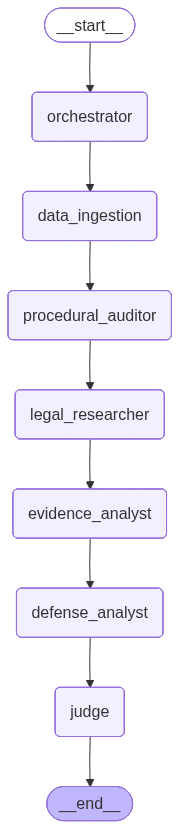

In [75]:
from IPython.display import display , Image

def get_graph_visualization() -> bytes:
    """Returns Mermaid diagram PNG bytes of the graph."""
    return legal_graph.get_graph().draw_mermaid_png()

display(Image(get_graph_visualization()))

In [72]:
# =============================================================================
#  SAMPLE CASE FACTORY
# =============================================================================

def create_sample_case() -> AgentState:
    """
    ينشئ قضية نموذجية كاملة (ضرب أفضى إلى موت) جاهزة للتشغيل.
    استخدمها للاختبار أو كمرجع لبنية الـ AgentState.

    Returns:
        AgentState مُعبَّأ بالكامل بكل كيانات القضية.

    Example:
        >>> state  = create_sample_case()
        >>> result = run_case(state)
    """
    return AgentState(
        case_id      = "CASE-2024-001",
        case_number  = "1234/2024 جنايات",
        court        = "محكمة جنايات القاهرة",
        court_level  = CourtLevel.CRIMINAL,
        jurisdiction = "دائرة الجنايات الأولى",
        filing_date  = datetime(2024, 3, 15),

        source_documents = [
            "amr_ihalah.pdf",
            "mahdar_dabt.pdf",
            "taqrir_tibbi.pdf",
            "aqwal_shuhud.pdf",
            "mozakart_difa.pdf",
        ],

        defendants = [
            Defendant(
                name            = "أحمد محمد علي",
                national_id     = "29001011234567",
                age             = 30,
                gender          = "ذكر",
                occupation      = "عامل",
                prior_record    = False,
                complicity_role = "فاعل أصلي",
                arrest_date     = datetime(2024, 1, 10),
                in_custody      = True,
            )
        ],

        charges = [
            Charge(
                charge_id         = "CHG-001",
                statute           = "ضرب أفضى إلى موت",
                law_code          = LawCode.PENAL,
                article_number    = "236",
                description       = "ضرب المجني عليه بآلة راضة أفضى إلى وفاته",
                elements_required = ["فعل الاعتداء", "الوفاة", "رابطة السببية", "القصد الجنائي"],
                elements_proven   = {
                    "فعل الاعتداء":  True,
                    "الوفاة":        True,
                    "رابطة السببية":  True,
                    "القصد الجنائي": False,
                },
                penalty_range  = "السجن المشدد من 3 إلى 15 سنة",
                attempt_flag   = False,
            )
        ],

        incidents = [
            CaseIncident(
                incident_id          = "INC-001",
                incident_type        = IncidentType.ASSAULT_FATAL,
                incident_date        = datetime(2024, 1, 9, 23, 30),
                incident_location    = "شارع النيل — الجيزة",
                incident_description = "تشاجر المتهم مع المجني عليه وضربه بعصا على رأسه فأودى بحياته",
                perpetrator_names    = ["أحمد محمد علي"],
                victim_names         = ["سعيد عبد الله"],
                outcome              = "وفاة المجني عليه",
                linked_evidence_ids  = ["EV-001", "EV-002"],
            )
        ],

        evidences = [
            Evidence(
                evidence_id             = "EV-001",
                evidence_type           = EvidenceType.MATERIAL,
                description             = "عصا خشبية مضبوطة بمكان الحادث",
                seizure_date            = datetime(2024, 1, 10, 2, 0),
                seizure_location        = "شارع النيل — الجيزة",
                seized_by               = "النقيب محمود حسن",
                seizure_warrant_present = False,
                chain_of_custody_ok     = True,
                validity_status         = ValidityStatus.VALID,
                linked_charge_elements  = ["فعل الاعتداء"],
            ),
            Evidence(
                evidence_id            = "EV-002",
                evidence_type          = EvidenceType.FORENSIC,
                description            = "تقرير الصفة التشريحية يثبت الوفاة من إصابة الرأس",
                validity_status        = ValidityStatus.VALID,
                linked_charge_elements = ["الوفاة", "رابطة السببية"],
            ),
        ],

        witness_statements = [
            WitnessStatement(
                witness_name               = "محمود سعيد",
                witness_type               = WitnessType.EYEWITNESS,
                relation_to_defendant      = "غريب",
                was_sworn_in               = True,
                statement_summary          = "رأيت المتهم يضرب المجني عليه بعصا على رأسه",
                consistency_flag           = True,
                contradicts_other_evidence = False,
            ),
            WitnessStatement(
                witness_name               = "فاطمة علي",
                witness_type               = WitnessType.DEFENSE,
                relation_to_defendant      = "قريب",
                was_sworn_in               = True,
                statement_summary          = "المتهم كان في المنزل وقت الحادث",
                consistency_flag           = False,
                contradicts_other_evidence = True,
                contradiction_details      = "يتعارض مع شهادة الشاهد الأول وتقارير الكاميرات",
            ),
        ],

        confessions = [
            Confession(
                confession_id         = "CONF-001",
                defendant_name        = "أحمد محمد علي",
                confession_date       = datetime(2024, 1, 11),
                confession_stage      = "نيابة",
                obtained_after_arrest = True,
                legal_counsel_present = False,
                informed_of_rights    = False,
                coercion_claimed      = True,
                coercion_evidence     = "آثار كدمات على جسم المتهم موثقة طبيًا",
                text                  = "اعترف بضرب المجني عليه دفاعًا عن النفس",
                voluntary             = False,
                consistent_with_facts = True,
                retracted             = True,
                retraction_reason     = "ادعى الإكراه أثناء المحاكمة",
            )
        ],

        procedural_issues = [
            ProceduralIssue(
                issue_id             = "PROC-001",
                procedure_type       = ProcedureType.INTERROGATION,
                conducting_authority = "شرطة",
                warrant_present      = False,
                notification_to_da   = False,
                issue_description    = "استجواب المتهم بدون حضور محامٍ أو إخطار النيابة",
                nullity_type         = NullityType.ABSOLUTE,
                article_basis        = "م 124 إجراءات جنائية",
                affects_evidence_ids = ["CONF-001"],
                tainted_fruit_risk   = True,
                may_invalidate_case  = True,
            )
        ],

        defense_documents = [
            DefenseDocument(
                doc_id               = "DEF-001",
                doc_type             = "مذكرة دفاع",
                submitted_by         = "المحامي عمر فاروق",
                formal_defenses      = ["بطلان الاعتراف لعدم حضور محامٍ", "بطلان الاستجواب"],
                substantive_defenses = ["انتفاء القصد الجنائي", "الدفاع الشرعي"],
                alibi_claimed        = True,
                alibi_details        = "المتهم كان في منزله وقت الحادث — شهادة زوجته",
                supporting_principles= ["نقض 21/1/1982 — الاعتراف الباطل لا يعتد به"],
            )
        ],
    )

In [55]:
# =============================================================================
#  RESULT PRINTER
# =============================================================================

def print_case_result(result: dict) -> None:
    """
    يطبع ملخصًا منسقًا لنتيجة القضية بعد تشغيل الـ graph.

    Args:
        result: القاموس المُعاد من run_case() أو legal_graph.invoke().

    Example:
        >>> state  = create_sample_case()
        >>> result = run_case(state)
        >>> print_case_result(result)
    """
    sep = "=" * 70

    print(f"\n{sep}")
    print("📋  CASE RESULT SUMMARY")
    print(sep)
    print(f"Case ID          : {result.get('case_id')}")
    print(f"Case Number      : {result.get('case_number')}")
    print(f"Court            : {result.get('court')}")
    print(f"Completed Agents : {result.get('completed_agents')}")
    print(f"Suggested Verdict: {result.get('suggested_verdict')}")
    print(f"Confidence Score : {result.get('confidence_score', 0.0):.2f}")
    print(f"Errors           : {result.get('errors') or 'None'}")

    outputs = result.get("agent_outputs", {})

    # ── Procedural Audit ──────────────────────────────────────────────────────
    audit = outputs.get("procedural_auditor", {})
    if audit:
        print(f"\n{'─'*70}")
        print("⚖️   PROCEDURAL AUDIT")
        print(f"{'─'*70}")
        print(f"Overall Validity  : {audit.get('overall_procedural_validity')}")
        print(f"Critical Nullities: {audit.get('critical_nullities') or 'None'}")
        print(f"Recommendation    : {audit.get('recommendation')}")

    # ── Evidence Matrix ───────────────────────────────────────────────────────
    evidence = outputs.get("evidence_analyst", {})
    if evidence:
        print(f"\n{'─'*70}")
        print("🔍  EVIDENCE ANALYSIS")
        print(f"{'─'*70}")
        print(f"Overall Strength  : {evidence.get('overall_evidence_strength', 0.0):.2f}")
        print(f"Key Strengths     : {evidence.get('key_strengths') or 'None'}")
        print(f"Key Weaknesses    : {evidence.get('key_weaknesses') or 'None'}")

    # ── Defense ───────────────────────────────────────────────────────────────
    defense = outputs.get("defense_analyst", {})
    if defense:
        print(f"\n{'─'*70}")
        print("🛡️   DEFENSE ANALYSIS")
        print(f"{'─'*70}")
        print(f"Defense Strength  : {defense.get('overall_defense_strength')}")
        print(f"Critical Points   : {defense.get('critical_defense_points') or 'None'}")

    # ── Judge ─────────────────────────────────────────────────────────────────
    judge = outputs.get("judge", {})
    if judge:
        print(f"\n{'─'*70}")
        print("👨‍⚖️   JUDGE DELIBERATION")
        print(f"{'─'*70}")
        print(f"Verdict           : {judge.get('verdict')}")
        print(f"Reasoning         : {judge.get('verdict_reasoning')}")
        print(f"Applicable Penalty: {judge.get('applicable_penalty')}")
        print(f"Deficiencies      : {judge.get('deficiencies') or 'None'}")
        print(f"Doubts            : {judge.get('doubts') or 'None'}")

    print(f"\n{sep}\n")

In [56]:
state  = create_sample_case()
result = run_case(state)
print_case_result(result)

2026-02-21 04:54:30,456 [INFO] 🚀 Starting legal pipeline for case: CASE-2024-001
2026-02-21 04:54:30,457 [INFO] 🎯 Orchestrator — Case: CASE-2024-001 | Completed: []
2026-02-21 04:54:30,458 [INFO] 📂 DataIngestion — entities already in state, skipping file read.
2026-02-21 04:54:30,459 [INFO] ⚖️  ProceduralAuditor — Reviewing 1 procedural issues
2026-02-21 04:54:32,077 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-21 04:54:32,078 [INFO] 📚 LegalResearcher — 1 charge(s)
2026-02-21 04:54:32,079 [INFO] Load pretrained SentenceTransformer: silma-ai/silma-embeddding-sts-v0.1
2026-02-21 04:54:37,521 [INFO] Loading laws index from disk …
2026-02-21 04:54:37,523 [INFO] Loading na2d indexes from disk …
2026-02-21 04:54:38,430 [INFO] ✓ Neo4j connected
2026-02-21 04:54:38,430 [INFO]   🔎 Charge: ضرب أفضى إلى موت
2026-02-21 04:54:38,465 [INFO]     📖 FAISS statutes: 6
2026-02-21 04:54:38,532 [INFO]     ⚖️  Cassation: 6 docs
2026-02-21 04:54:41,630 [


📋  CASE RESULT SUMMARY
Case ID          : CASE-2024-001
Case Number      : 1234/2024 جنايات
Court            : محكمة جنايات القاهرة
Completed Agents : ['data_ingestion', 'procedural_auditor', 'legal_researcher', 'evidence_analyst', 'defense_analyst', 'judge']
Suggested Verdict: VerdictType.ACQUITTAL
Confidence Score : 0.70
Errors           : None

──────────────────────────────────────────────────────────────────────
⚖️   PROCEDURAL AUDIT
──────────────────────────────────────────────────────────────────────
Overall Validity  : سليم
Critical Nullities: None
Recommendation    : مراجعة صحة الأدلة المتأثرة بالبطلان المطلق

──────────────────────────────────────────────────────────────────────
🔍  EVIDENCE ANALYSIS
──────────────────────────────────────────────────────────────────────
Overall Strength  : 0.00
Key Strengths     : None
Key Weaknesses    : None

──────────────────────────────────────────────────────────────────────
🛡️   DEFENSE ANALYSIS
───────────────────────────────────────